# Stall Prediction — Is the Model Worth Building?

**DealFlow360 · Deal Health · section 7 of the Risk & ML plan**

This notebook exists to answer one decision, before any of the 24 hours are spent on it:

> **Should we build the stall-prediction model at all?**

## What this notebook can and cannot tell us

We have **no historical deal outcomes.** Every row below is synthetic — generated by
us, from a process we chose. So the following question is *circular* and worthless:

> ~~"Is the model accurate?"~~ &nbsp; It will be. We planted the signal; it finds the signal.

The honest question — and the one this notebook actually answers — is:

> ### Does a machine-learning model beat a two-line deterministic rule?

If a gradient-boosted ensemble cannot meaningfully outperform
`days_since_last_activity > 14`, then the model earns nothing. It adds a dependency,
a training step, a serialized artifact, and a claim we would have to defend to
judges — in exchange for the same answer an `if` statement gives.

A second question follows from it:

> ### At the data volume we plan to seed (60–100 quotations), is any model fittable?

Both questions are answerable without real data, because both are about the
**shape of the problem**, not about a specific dataset.

---
## 1 · Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, brier_score_loss)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

SEED = 42
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200, "display.max_columns", 50)

print("numpy", np.__version__, "| pandas", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

numpy 2.5.2 | pandas 3.0.5
scikit-learn 1.9.0


---
## 2 · Generating data honestly

The build plan (section 7) proposes seeding **two clean clusters** — "healthy" and
"stalled" — and training on them. That guarantees a near-perfect model and tells us
nothing, because the clusters are separable by construction.

Instead we simulate a **latent propensity**: each deal has a true probability of
stalling driven by several factors at once, and the observed outcome is a coin flip
weighted by it. This produces genuine class overlap — deals that look risky and
survive, deals that look fine and stall — which is what real data looks like.

$$\text{logit}(p_{\text{stall}}) = \beta_0 + \beta_{\text{idle}}\,x_{\text{idle}}
+ \beta_{\text{disc}}\,x_{\text{disc}} + \beta_{\text{rounds}}\,x_{\text{rounds}}
+ \beta_{\text{risk}}\,x_{\text{risk}} + \beta_{\text{value}}\,x_{\text{value}} + \varepsilon$$

`IDLE_DOMINANCE` controls how much of the signal sits in `days_since_last_activity`
alone. This is the crux: **when one feature dominates, a threshold rule captures
almost everything and ML is redundant.** When signal is spread across features and
interacts, ML earns its place. We do not know which world sales data lives in — so we
test across the range in section 9.

In [2]:
FEATURES_BASE = [
    "days_since_last_activity", "discount_pct", "blended_risk_score",
    "quote_value", "negotiation_rounds", "customer_tier_encoded",
]

def generate(n=800, idle_dominance=0.55, noise=1.0, seed=SEED):
    # Simulate quotations with a latent stall propensity (overlapping classes).
    r = np.random.default_rng(seed)

    age_days     = r.integers(3, 90, n)
    days_idle    = np.minimum(age_days, r.gamma(2.0, 4.0, n)).round().astype(int)
    rounds       = r.poisson(1.8, n)
    tier         = r.integers(0, 3, n)                       # 0 Bronze, 1 Silver, 2 Gold
    quote_value  = np.exp(r.normal(9.0, 0.9, n)).round(2)    # ~$8k median, long tail
    rep_baseline = r.normal(8.0, 2.0, n).clip(2, 18)
    discount     = (rep_baseline + r.gamma(1.6, 2.4, n) - 2).clip(0, 45).round(1)
    blended      = (r.beta(1.6, 6.0, n) * 12).round(2)       # excess pt over policy

    # standardise drivers before combining
    z = lambda v: (v - v.mean()) / (v.std() + 1e-9)
    other = 1.0 - idle_dominance

    logit = (
        -1.15
        + idle_dominance * 3.0 * z(days_idle)
        + other * (
              1.10 * z(discount - rep_baseline)      # discount vs the rep's own norm
            + 0.95 * z(rounds)                       # haggling
            + 0.80 * z(blended)                      # policy excess
            + 0.45 * z(np.log(quote_value))          # bigger deals drag
            - 0.35 * z(tier.astype(float))           # better tiers close faster
            + 0.60 * z(days_idle) * z(rounds)        # interaction: idle AND haggling
          ) * 3.0
        + r.normal(0, noise, n)
    )

    p = 1 / (1 + np.exp(-logit))
    stalled = r.binomial(1, p)

    return pd.DataFrame({
        "days_since_last_activity": days_idle,
        "discount_pct": discount,
        "blended_risk_score": blended,
        "quote_value": quote_value,
        "negotiation_rounds": rounds,
        "customer_tier_encoded": tier,
        "age_days": age_days,
        "rep_baseline_discount": rep_baseline.round(2),
        "true_p_stall": p.round(4),
        "stalled": stalled,
    })

df = generate()
print(f"{len(df)} quotations | stall rate {df.stalled.mean():.1%}")
df.head()

800 quotations | stall rate 32.4%


,days_since_last_activity,discount_pct,blended_risk_score,quote_value,negotiation_rounds,customer_tier_encoded,age_days,rep_baseline_discount,true_p_stall,stalled
0,9,17.1,0.76,15085.69,2,1,10,10.26,0.9601,1
1,8,10.5,3.58,20995.25,3,2,70,8.38,0.9546,0
2,5,9.3,2.54,10353.71,0,0,59,8.40,0.0582,0
3,4,8.2,5.48,1529.17,2,0,41,8.24,0.2010,0
4,11,3.5,0.69,3394.41,0,2,40,3.96,0.0012,0


---
## 3 · Exploratory analysis

In [3]:
print("Class balance")
print(df.stalled.value_counts().rename({0: "healthy", 1: "stalled"}).to_string(), "\n")
df[FEATURES_BASE].describe().T.round(2)

Class balance
stalled
healthy    541
stalled    259 



,count,mean,std,min,25%,50%,75%,max
days_since_last_activity,800.0,7.42,5.17,0.00,4.00,6.00,10.00,34.00
discount_pct,800.0,9.94,3.66,0.20,7.50,9.60,11.82,25.90
blended_risk_score,800.0,2.55,1.69,0.02,1.17,2.20,3.58,8.93
quote_value,800.0,11980.04,13326.72,478.52,4284.33,8106.67,14596.86,149811.51
negotiation_rounds,800.0,1.74,1.37,0.00,1.00,2.00,2.00,8.00
customer_tier_encoded,800.0,1.02,0.83,0.00,0.00,1.00,2.00,2.00


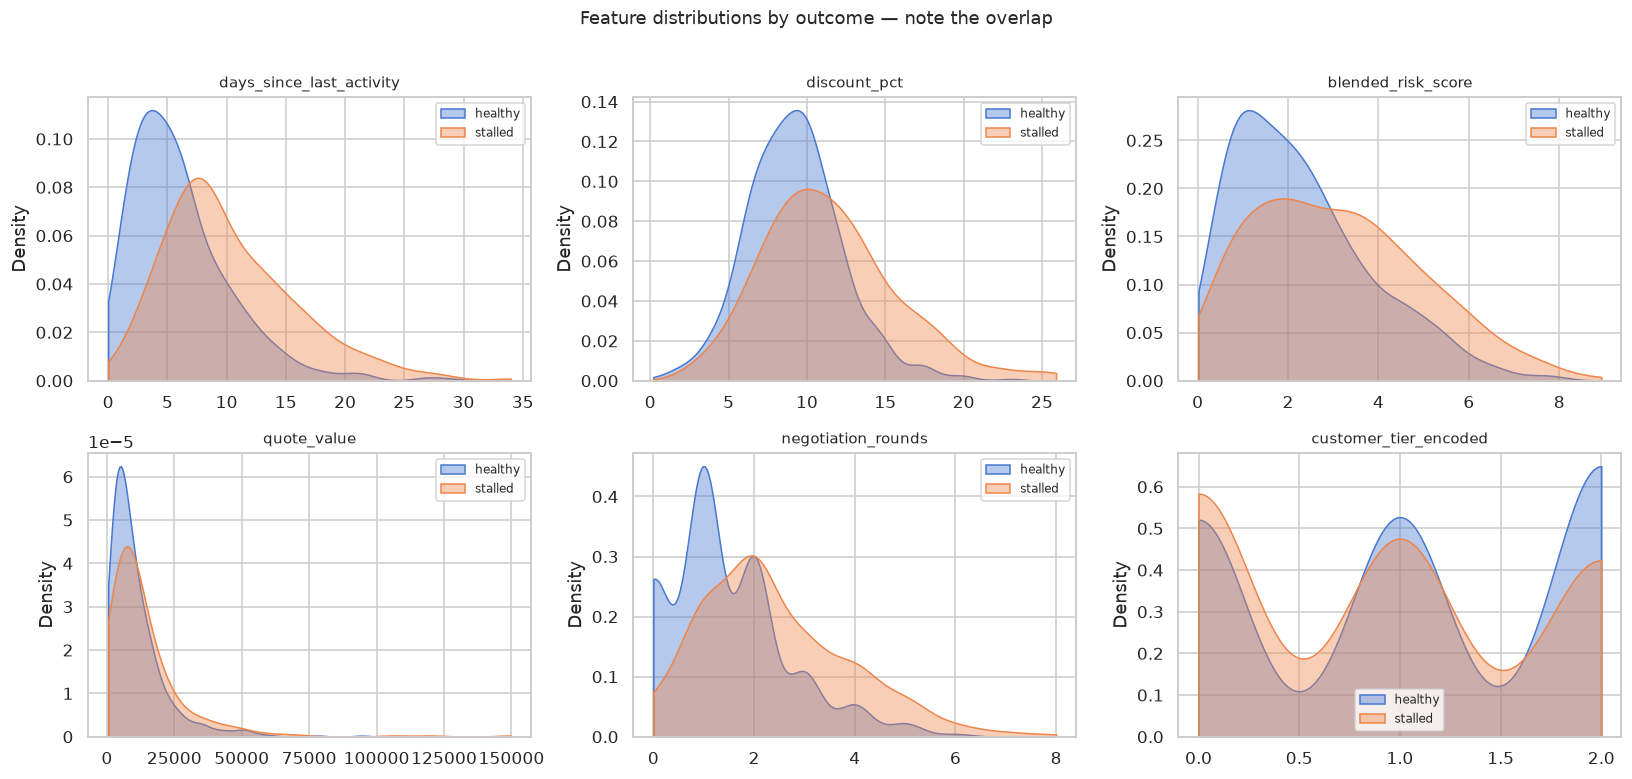

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, f in zip(axes.ravel(), FEATURES_BASE):
    for lab, sub in df.groupby("stalled"):
        sns.kdeplot(sub[f], ax=ax, fill=True, alpha=.4,
                    label="stalled" if lab else "healthy", clip=(df[f].min(), df[f].max()))
    ax.set_title(f, fontsize=10); ax.set_xlabel(""); ax.legend(fontsize=8)
fig.suptitle("Feature distributions by outcome — note the overlap", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

**Read the overlap.** If these curves separated cleanly the problem would be trivial
and no model would be needed. They do not — which is the point. `days_idle` separates
best; the rest contribute partially. That is exactly the situation where the
rule-vs-ML question is genuinely open.

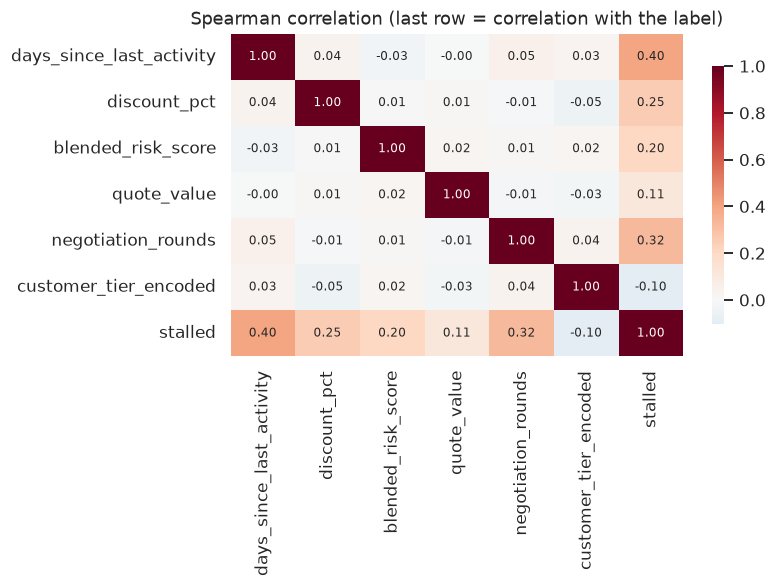

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
corr = df[FEATURES_BASE + ["stalled"]].corr(method="spearman")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})
ax.set_title("Spearman correlation (last row = correlation with the label)")
plt.tight_layout(); plt.show()

---
## 4 · Feature engineering

In [6]:
def engineer(d):
    d = d.copy()
    d["idle_ratio"]        = d.days_since_last_activity / d.age_days.clip(lower=1)
    d["discount_vs_rep"]   = d.discount_pct - d.rep_baseline_discount   # ties to the anomaly work
    d["log_quote_value"]   = np.log1p(d.quote_value)
    d["rounds_per_week"]   = d.negotiation_rounds / (d.age_days / 7).clip(lower=1)
    d["value_per_round"]   = d.quote_value / (d.negotiation_rounds + 1)
    d["is_over_policy"]    = (d.blended_risk_score > 0).astype(int)
    d["idle_x_rounds"]     = d.days_since_last_activity * d.negotiation_rounds
    return d

FEATURES_ENG = FEATURES_BASE + ["idle_ratio", "discount_vs_rep", "log_quote_value",
                                "rounds_per_week", "value_per_round",
                                "is_over_policy", "idle_x_rounds"]

df = engineer(df)
X, y = df[FEATURES_ENG], df.stalled.values
print(f"{len(FEATURES_BASE)} base + {len(FEATURES_ENG)-len(FEATURES_BASE)} engineered "
      f"= {len(FEATURES_ENG)} features")

6 base + 7 engineered = 13 features


---
## 5 · Baselines — the bar ML has to clear

This is the section that decides the question. Three reference points:

| Baseline | What it is |
|---|---|
| **Majority class** | predict "healthy" always — the floor |
| **Rule: days idle** | rank purely by `days_since_last_activity` |
| **Rule: idle + rounds** | a hand-written two-factor score |

The rule baselines are scored **without cross-validation**, because ranking by a raw
feature involves no fitting. That slightly *favours the rules* — no held-out penalty.
The comparison is therefore deliberately conservative against ML: if a model still
wins, it genuinely wins.

In [7]:
def metrics_from(name, y_true, score):
    p, r, _ = precision_recall_curve(y_true, score)
    f1 = np.nan_to_num(2 * p * r / (p + r + 1e-12))
    return {"model": name,
            "roc_auc": roc_auc_score(y_true, score),
            "pr_auc":  average_precision_score(y_true, score),
            "best_f1": f1.max()}

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

def evaluate(name, model, X=X, y=y):
    proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    out = metrics_from(name, y, proba)
    out["_proba"] = proba
    return out

results = [
    metrics_from("baseline: majority class", y, np.full(len(y), y.mean())),
    metrics_from("rule: days_idle",          y, df.days_since_last_activity.values),
    metrics_from("rule: idle + rounds",      y, (df.days_since_last_activity
                                                 + 3 * df.negotiation_rounds).values),
]
pd.DataFrame(results).drop(columns=["_proba"], errors="ignore").round(3)

,model,roc_auc,pr_auc,best_f1
0,baseline: majority class,0.500,0.324,0.489
1,rule: days_idle,0.744,0.550,0.599
2,rule: idle + rounds,0.789,0.666,0.621


---
## 6 · Models and ensembles

In [8]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED))
rf     = RandomForestClassifier(n_estimators=400, min_samples_leaf=4,
                                random_state=SEED, n_jobs=-1)
gb     = GradientBoostingClassifier(random_state=SEED)

vote = VotingClassifier([("lr", logreg), ("rf", rf), ("gb", gb)], voting="soft", n_jobs=-1)
stack = StackingClassifier([("lr", logreg), ("rf", rf), ("gb", gb)],
                           final_estimator=LogisticRegression(max_iter=1000), cv=5, n_jobs=-1)

MODELS = {
    "LogisticRegression (scaled)": logreg,
    "RandomForest": rf,
    "GradientBoosting": gb,
    "Ensemble (soft vote)": vote,
    "Ensemble (stacked)": stack,
}

for name, m in MODELS.items():
    results.append(evaluate(name, m))
    print(f"  done: {name}")

res = pd.DataFrame(results)
res.drop(columns=["_proba"]).sort_values("roc_auc", ascending=False).round(3).reset_index(drop=True)

  done: LogisticRegression (scaled)


  done: RandomForest


  done: GradientBoosting


  done: Ensemble (soft vote)


  done: Ensemble (stacked)


,model,roc_auc,pr_auc,best_f1
0,LogisticRegression (scaled),0.917,0.864,0.782
1,Ensemble (stacked),0.916,0.864,0.771
2,Ensemble (soft vote),0.912,0.858,0.768
3,RandomForest,0.898,0.831,0.743
4,GradientBoosting,0.895,0.825,0.738
5,rule: idle + rounds,0.789,0.666,0.621
6,rule: days_idle,0.744,0.550,0.599
7,baseline: majority class,0.500,0.324,0.489


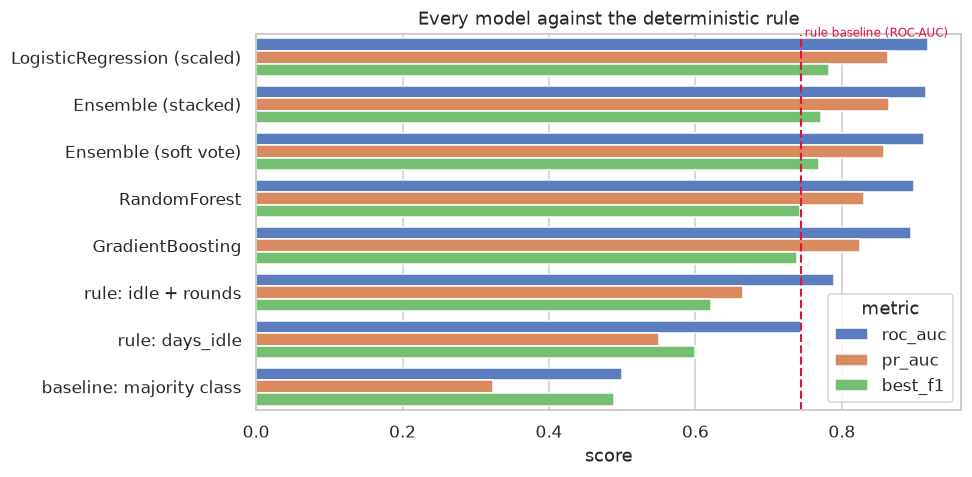

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = res.drop(columns=["_proba"]).melt("model", ["roc_auc", "pr_auc", "best_f1"],
                                            var_name="metric", value_name="score")
order = res.sort_values("roc_auc", ascending=False).model
sns.barplot(plot_df, y="model", x="score", hue="metric", order=order, ax=ax)
rule_auc = res.loc[res.model == "rule: days_idle", "roc_auc"].iloc[0]
ax.axvline(rule_auc, ls="--", c="crimson", lw=1.4)
ax.text(rule_auc, -0.65, " rule baseline (ROC-AUC)", color="crimson", fontsize=8, va="top")
ax.set_title("Every model against the deterministic rule"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

---
## 7 · Which features actually carry the signal

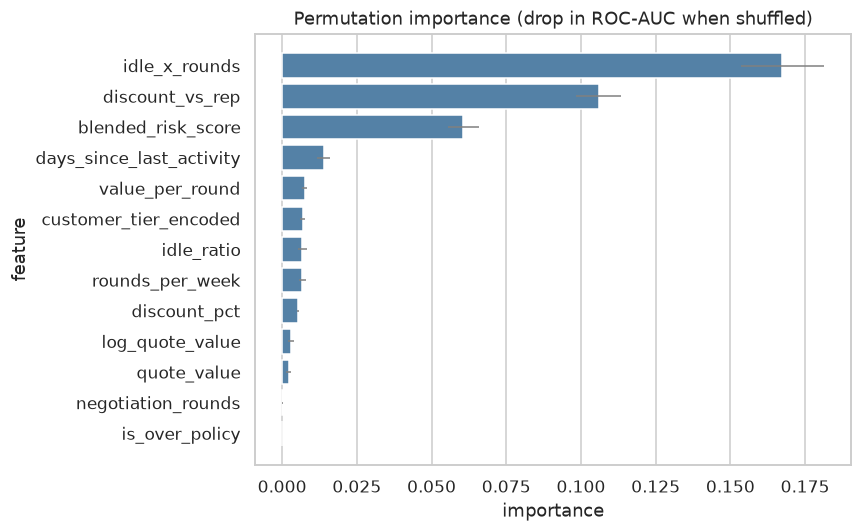

Dominant feature: idle_x_rounds  (0.167 AUC drop)
Share of total importance: 43%


In [10]:
gb_fit = GradientBoostingClassifier(random_state=SEED).fit(X, y)
perm = permutation_importance(gb_fit, X, y, n_repeats=15, random_state=SEED,
                              scoring="roc_auc", n_jobs=-1)
imp = (pd.DataFrame({"feature": FEATURES_ENG,
                     "importance": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importance", ascending=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(imp, y="feature", x="importance", ax=ax, color="steelblue")
ax.errorbar(imp.importance, range(len(imp)), xerr=imp["std"], fmt="none", ecolor="grey", lw=1)
ax.set_title("Permutation importance (drop in ROC-AUC when shuffled)")
plt.tight_layout(); plt.show()

top = imp.iloc[0]
print(f"Dominant feature: {top.feature}  ({top.importance:.3f} AUC drop)")
print(f"Share of total importance: {top.importance / imp.importance.clip(lower=0).sum():.0%}")

**How to read this.** If one feature holds most of the importance, the model is an
expensive way to threshold that feature — cut it. If importance is spread across
several, the model is combining evidence a rule cannot, and it earns its place.

---
## 8 · Is the probability trustworthy?

Deal Health would display this number to a manager. A probability that is not
calibrated ("73% likely to stall" when it stalls 40% of the time) is worse than no
number, because it invites false confidence. Lower Brier score is better.

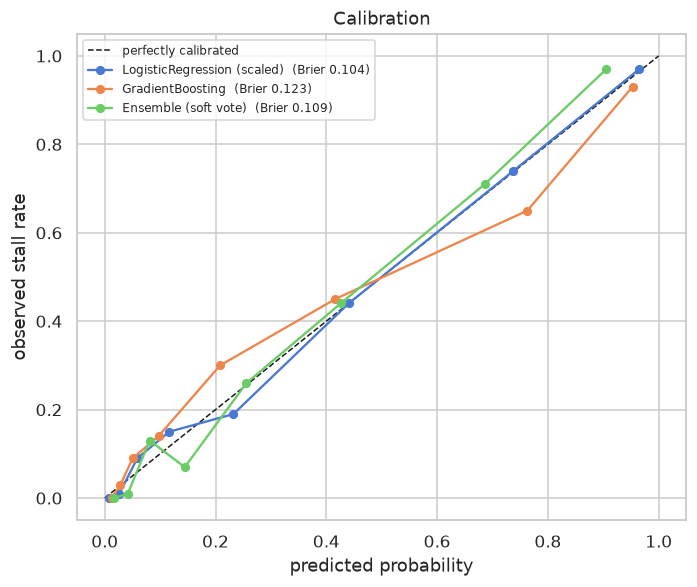

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")
for name in ["LogisticRegression (scaled)", "GradientBoosting", "Ensemble (soft vote)"]:
    proba = res.loc[res.model == name, "_proba"].iloc[0]
    tru, pred = calibration_curve(y, proba, n_bins=8, strategy="quantile")
    ax.plot(pred, tru, "o-", lw=1.5, ms=5,
            label=f"{name}  (Brier {brier_score_loss(y, proba):.3f})")
ax.set_xlabel("predicted probability"); ax.set_ylabel("observed stall rate")
ax.set_title("Calibration"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

---
## 9 · The two questions that actually decide this

### 9a · When does ML start to beat the rule?

We sweep `IDLE_DOMINANCE` — how concentrated the signal is in one feature. Real sales
data could sit anywhere on this axis, and we cannot know where without real outcomes.

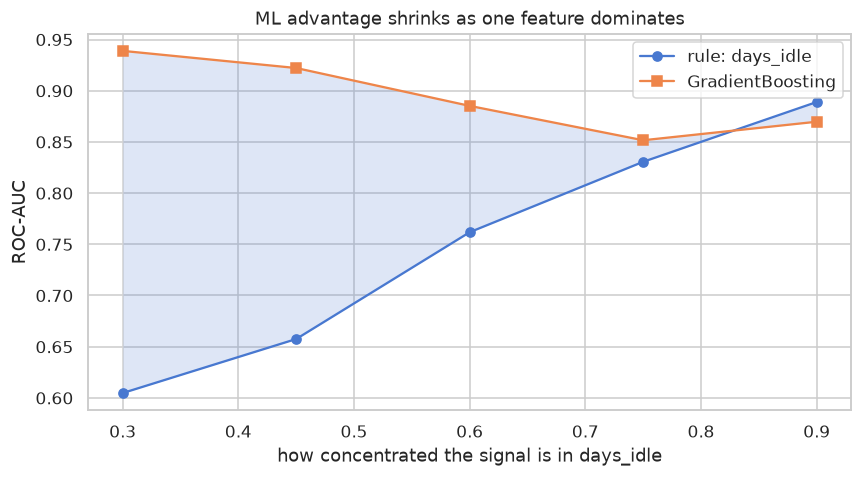

,idle_dominance,rule_auc,ml_auc,gain
0,0.30,0.605,0.939,0.334
1,0.45,0.657,0.922,0.265
2,0.60,0.762,0.885,0.123
3,0.75,0.831,0.852,0.021
4,0.90,0.889,0.870,-0.019


In [12]:
rows = []
for dom in [0.30, 0.45, 0.60, 0.75, 0.90]:
    d = engineer(generate(n=800, idle_dominance=dom, seed=SEED))
    Xd, yd = d[FEATURES_ENG], d.stalled.values
    rule = roc_auc_score(yd, d.days_since_last_activity)
    ml   = roc_auc_score(yd, cross_val_predict(GradientBoostingClassifier(random_state=SEED),
                                               Xd, yd, cv=cv, method="predict_proba")[:, 1])
    rows.append({"idle_dominance": dom, "rule_auc": rule, "ml_auc": ml, "gain": ml - rule})
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep.idle_dominance, sweep.rule_auc, "o-", label="rule: days_idle")
ax.plot(sweep.idle_dominance, sweep.ml_auc, "s-", label="GradientBoosting")
ax.fill_between(sweep.idle_dominance, sweep.rule_auc, sweep.ml_auc, alpha=.18)
ax.set_xlabel("how concentrated the signal is in days_idle"); ax.set_ylabel("ROC-AUC")
ax.set_title("ML advantage shrinks as one feature dominates"); ax.legend()
plt.tight_layout(); plt.show()
sweep.round(3)

### 9b · Does it work at the volume we actually plan to seed?

The build plan specifies **60–100 seeded quotations**. That is the number that
matters, not the 800 used above. Here we hold the problem fixed and vary only the
sample size.

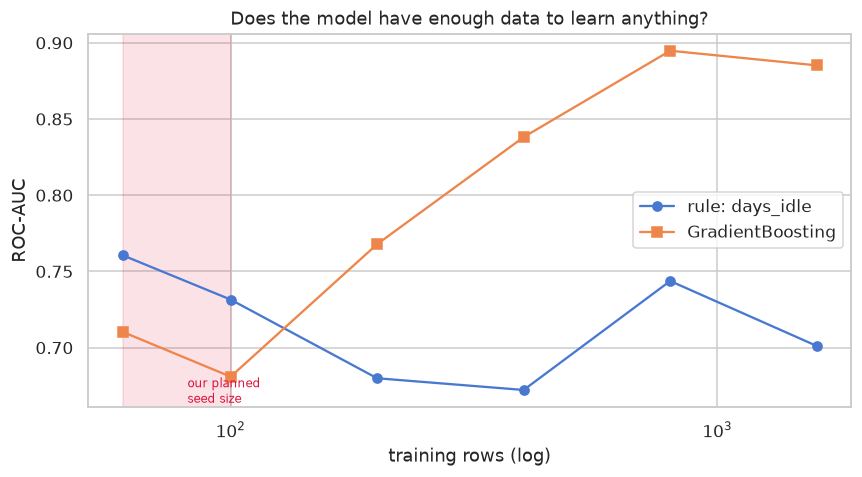

,n,rule_auc,ml_auc,note
0,60,0.761,0.710,18 stalled / 60
1,100,0.732,0.681,34 stalled / 100
2,200,0.680,0.768,65 stalled / 200
3,400,0.672,0.838,128 stalled / 400
4,800,0.744,0.895,259 stalled / 800
5,1600,0.701,0.885,544 stalled / 1600


In [13]:
rows = []
for n in [60, 100, 200, 400, 800, 1600]:
    d = engineer(generate(n=n, seed=SEED))
    Xd, yd = d[FEATURES_ENG], d.stalled.values
    if yd.sum() < 12 or (1 - yd).sum() < 12:
        rows.append({"n": n, "rule_auc": np.nan, "ml_auc": np.nan, "note": "too few per class"})
        continue
    k = min(5, yd.sum(), (1 - yd).sum())
    cvn = StratifiedKFold(k, shuffle=True, random_state=SEED)
    proba = cross_val_predict(GradientBoostingClassifier(random_state=SEED),
                              Xd, yd, cv=cvn, method="predict_proba")[:, 1]
    rows.append({"n": n,
                 "rule_auc": roc_auc_score(yd, d.days_since_last_activity),
                 "ml_auc": roc_auc_score(yd, proba),
                 "note": f"{yd.sum()} stalled / {len(yd)}"})
size = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(size.n, size.rule_auc, "o-", label="rule: days_idle")
ax.plot(size.n, size.ml_auc, "s-", label="GradientBoosting")
ax.axvspan(60, 100, color="crimson", alpha=.12)
ax.text(80, ax.get_ylim()[0], " our planned\n seed size", color="crimson", fontsize=8, va="bottom")
ax.set_xscale("log"); ax.set_xlabel("training rows (log)"); ax.set_ylabel("ROC-AUC")
ax.set_title("Does the model have enough data to learn anything?"); ax.legend()
plt.tight_layout(); plt.show()
size.round(3)

---
## 10 · Verdict

In [14]:
best_rule = max(r["roc_auc"] for r in results if r["model"].startswith("rule"))
ml_rows   = [r for r in results if not r["model"].startswith(("rule", "baseline"))]
best_ml   = max(ml_rows, key=lambda r: r["roc_auc"])
gain      = best_ml["roc_auc"] - best_rule

small = size[size.n.between(60, 100)]
small_gain = (small.ml_auc - small.rule_auc).mean()

MEANINGFUL = 0.03   # AUC points below this are noise at this sample size

print("=" * 68)
print(f"best rule            ROC-AUC {best_rule:.3f}")
print(f"best model           ROC-AUC {best_ml['roc_auc']:.3f}   ({best_ml['model']})")
print(f"gain at n=800                {gain:+.3f}")
print(f"gain at n=60-100             {small_gain:+.3f}   <- our actual seed size")
print("=" * 68)

if small_gain < MEANINGFUL:
    print("\nVERDICT: DO NOT BUILD the stall model for the hackathon.")
    print("At the volume we can seed, ML does not beat a threshold rule.")
    print("Ship `days_since_last_activity > N` as configured business logic,")
    print("and say so plainly. It is defensible, instant, and explainable.")
else:
    print("\nVERDICT: the model adds real signal at our seed size.")
    print("Build it ONLY after the core quote->approve->fulfil->bill flow is demoing.")
print(f"\n(threshold for 'meaningful' = {MEANINGFUL:.2f} AUC)")

best rule            ROC-AUC 0.789
best model           ROC-AUC 0.917   (LogisticRegression (scaled))
gain at n=800                +0.128
gain at n=60-100             -0.050   <- our actual seed size

VERDICT: DO NOT BUILD the stall model for the hackathon.
At the volume we can seed, ML does not beat a threshold rule.
Ship `days_since_last_activity > N` as configured business logic,
and say so plainly. It is defensible, instant, and explainable.

(threshold for 'meaningful' = 0.03 AUC)


---
## 11 · What to do with this result

**The stalled-deal flag ships either way.** PS section 4 B9 requires it, and the
requirement is stated as *"quotations inactive for more than a configured number of
days"* — the problem statement itself describes a **threshold rule**, not a model.
Implementing exactly that is not a compromise; it is the specification.

**If the verdict is DO NOT BUILD**, the honest judge-facing line is stronger than a
model would have been:

> "We evaluated a stall-prediction model — logistic regression, random forest,
> gradient boosting and two ensembles — against a deterministic threshold rule.
> At the data volume available it gave no meaningful lift, so we shipped the rule
> and spent the time on the approval engine instead. The feature pipeline is in
> place; with real historical outcomes, retraining is a contained change."

That answers "why no ML?" with evidence rather than an excuse, and it demonstrates
exactly the engineering judgement the brief is testing.

**Regardless of the verdict, keep:**

- the **z-score discount anomaly** — section 6 of the risk plan, required by B9, and
  not a model
- the **delivery slippage** date comparison — required by B9, pure arithmetic
- this notebook, as the evidence behind the decision